Epoch   0 | Loss: 31.8165 | w: 0.1833 | b: 0.0406
Epoch  50 | Loss: 0.8368 | w: 2.8756 | b: 1.3054
Epoch 100 | Loss: 0.3133 | w: 2.9900 | b: 1.7661
Epoch 150 | Loss: 0.2503 | w: 2.9949 | b: 1.9338

Final learned values: w = 2.9951, b = 1.9942
True values:          w = 3.0000, b = 2.0000
Saved: training_loss.png


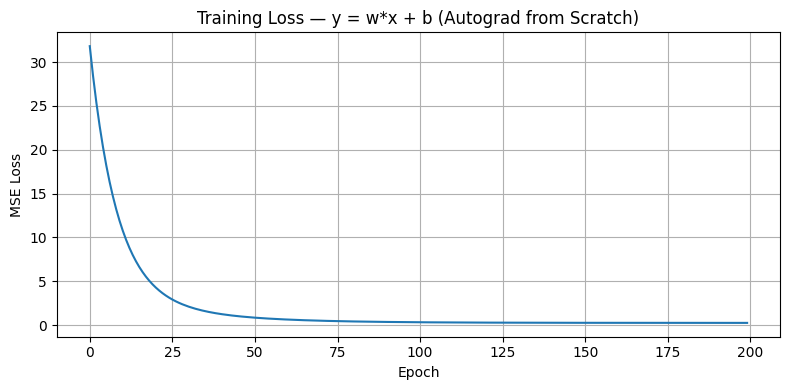

In [2]:
# Day B-3: PyTorch Tensors + Autograd from Scratch
# Goal: implement y = w*x + b manually, compute MSE loss, backprop, update weights

import torch
import matplotlib.pyplot as plt

# ─── 1. Create synthetic data ────────────────────────────────────────────
# True relationship: y = 3x + 2
torch.manual_seed(42)
X = torch.linspace(-3, 3, 100)          # 100 input values
Y = 3 * X + 2 + torch.randn(100) * 0.5  # true line + small noise

# ─── 2. Initialize weights (random guesses) ──────────────────────────────
w = torch.tensor(0.0, requires_grad=True)   # weight (should converge to ~3)
b = torch.tensor(0.0, requires_grad=True)   # bias  (should converge to ~2)

lr = 0.01       # learning rate
n_epochs = 200  # number of training steps
losses = []

# ─── 3. Training loop ────────────────────────────────────────────────────
for epoch in range(n_epochs):
    # Forward pass: predict Y from X
    Y_pred = w * X + b

    # Compute MSE loss: average squared difference
    loss = ((Y_pred - Y) ** 2).mean()
    losses.append(loss.item())

    # Backward pass: compute gradients
    loss.backward()

    # Update weights manually (gradient descent)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # CRITICAL: clear gradients before next pass
    w.grad.zero_()
    b.grad.zero_()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | w: {w.item():.4f} | b: {b.item():.4f}")

print(f"\nFinal learned values: w = {w.item():.4f}, b = {b.item():.4f}")
print(f"True values:          w = 3.0000, b = 2.0000")

# ─── 4. Plot training loss ───────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss — y = w*x + b (Autograd from Scratch)")
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=100)
print("Saved: training_loss.png")


# ─── Answer these questions in comments at the bottom of this file ───

## Q: What does requires_grad=True do?
### A: requires_grad=True tracks the gradient on the tensor. It's like telling the torch that 'Hey Torch! track this number, I am gonna need this later.' Gradient is basically like a compass to right direction of a tensor.

## Q: Why do we call zero_grad() at the end of each loop iteration?
### A: Pytorch accumulates gradients. If we don't reset the tracked gradients of the previous run, it will add up and mees up the calculations.

## Q: What would happen if we forgot the `with torch.no_grad():` block?
### A: We will run out of memory soon or the process will become very slow, as it will take huge chunk of memory to calculate gradients of each points repetatively while updating weights.